# Fine-tuned Model + CNN Microphone Recording Demo
### Install and Import Libraries

In [2]:
!pip install librosa matplotlib numpy pandas pydub pretty_midi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 49.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.4 MB/s eta 0:00:00
  Created wheel for pretty_midi: filename=pretty_midi-0.2.11-py3-none-any.whl size=5595886 sha256=2e87e57fd5069c1eb7f2a78eb9dbee9859c01dcf3eda7a5f8e90d38a21b3e4eb
  Stored in directory: /root/.cache/pip/wheels/f4/ad/93/a7042fe12668827574927ade9deec7f29aad2a1001b1501882
Successfully built pretty_midi


In [3]:
# ========================
# System / File Handling
# ========================
import os
import pickle
from io import BytesIO
from base64 import b64decode

# ========================
# Data Handling
# ========================
import numpy as np
import pandas as pd

# ========================
# Audio Processing
# ========================
import librosa
import librosa.display
import pretty_midi
import pydub

# ========================
# Machine Learning / Deep Learning
# ========================
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel, AutoProcessor
from peft import PeftModel

# ========================
# Visualization
# ========================
import matplotlib.pyplot as plt

# ========================
# Google Colab Utilities
# ========================
from google.colab import drive, output

# ========================
# Interactive / Display
# ========================
import IPython

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


In [4]:
# Clone the repository to access the reference MIDI files
!git clone https://github.com/mperumal-usd/capstone_team_3.git
MIDI_ROOT = "/content/capstone_team_3/MidiDatasets/590-Classical-music-midi"

Cloning into 'capstone_team_3'...
remote: Enumerating objects: 5362, done.
remote: Counting objects: 100% (149/149), done.
remote: Compressing objects: 100% (111/111), done.
remote: Total 5362 (delta 55), reused 65 (delta 32), pack-reused 5213 (from 2)
Receiving objects: 100% (5362/5362), 69.85 MiB | 22.65 MiB/s, done.
Resolving deltas: 100% (343/343), done.
Updating files: 100% (6378/6378), done.


# MyDrive Shortcut Setup
Open the Shared Drive or the Shared with me section in your Google Drive.

Download the following files:
1) adapter_model.safetensors - https://drive.google.com/drive/u/1/folders/1ACWI_rjz5uXnk8UZmXCjzWOCsf7AJ2g2
2) adapter_config.json
3) all_embeddings.pkl - https://drive.google.com/file/d/1CPxkjS4eegrNHGfEyqpRGNuBBdCB_H-L/view?usp=sharing

Download to "My Drive/AAI-590 Capstone/model_embed"

In [5]:
# 0. Mount Google Drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [6]:
!ls "/content/drive/MyDrive/AAI-590 Capstone/"

ChunkSamples  model_embed


# Load base MERT model

In [7]:
# Section 1 - load base model

# Model Configuration
MODEL_NAME = "m-a-p/MERT-v1-95M"
SR = 24000
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Load the Base MERT Model & Processor
processor = AutoProcessor.from_pretrained(MODEL_NAME, trust_remote_code=True)
base_model = AutoModel.from_pretrained(MODEL_NAME, trust_remote_code=True).to(DEVICE)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/211 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

configuration_MERT.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/m-a-p/MERT-v1-95M:
- configuration_MERT.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
The image processor of type `Wav2Vec2ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
`use_fast` is set to `True` but the image processor class does not have a fast version.  Falling back to the slow version.


modeling_MERT.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/m-a-p/MERT-v1-95M:
- modeling_MERT.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

# Load fine-tuned LoRA weights
adapter_config.json and adapter_model.safetensors

In [8]:
# Point to the FOLDER, not the .safetensors file
# Define your project directory
DRIVE_PATH = "/content/drive/MyDrive/AAI-590 Capstone/model_embed"
LORA_FOLDER_PATH = DRIVE_PATH

print(f"Loading LoRA weights from folder: {LORA_FOLDER_PATH}")

# PEFT looks for adapter_config.json and adapter_model.safetensors inside this folder
model = PeftModel.from_pretrained(base_model, LORA_FOLDER_PATH).to(DEVICE)
model.eval()

Loading LoRA weights from folder: /content/drive/MyDrive/AAI-590 Capstone/model_embed


PeftModel(
  (base_model): LoraModel(
    (model): MERTModel(
      (feature_extractor): HubertFeatureEncoder(
        (conv_layers): ModuleList(
          (0): HubertGroupNormConvLayer(
            (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
            (activation): GELUActivation()
            (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
          )
          (1-4): 4 x HubertNoLayerNormConvLayer(
            (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
            (activation): GELUActivation()
          )
          (5-6): 2 x HubertNoLayerNormConvLayer(
            (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
            (activation): GELUActivation()
          )
        )
      )
      (feature_projection): MERTFeatureProjection(
        (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (projection): Linear(in_features=512, out_features=768, bias=True)
        (dropout): Dr

# Load CNN Head Checkpoint "cnn_head_best.pt"

In [74]:
# Defining the CNN architecture from the v5 training notebook
# 1. CNN ARCHITECTURE
class CNNProjectionHead(nn.Module):
    def __init__(self, input_dim=768, output_dim=128):
        super().__init__()

        # Set track_running_stats=True because your checkpoint HAS these keys for convs
        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(input_dim, 256, kernel_size=3, padding=1),
                nn.BatchNorm1d(256, track_running_stats=True),
                nn.ReLU()
            ),
            nn.Sequential(
                nn.Conv1d(input_dim, 256, kernel_size=5, padding=2),
                nn.BatchNorm1d(256, track_running_stats=True),
                nn.ReLU()
            ),
            nn.Sequential(
                nn.Conv1d(input_dim, 256, kernel_size=7, padding=3),
                nn.BatchNorm1d(256, track_running_stats=True),
                nn.ReLU()
            )
        ])

        self.pool = nn.AdaptiveAvgPool1d(1)

        self.proj = nn.Sequential(
            nn.Linear(768, 384),
            nn.BatchNorm1d(384, track_running_stats=True), # Keep True to avoid crash in .eval()
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(384, output_dim)
        )

    def forward(self, x):
        if x.dim() == 2: x = x.unsqueeze(0) # Ensure [Batch, Time, Feat]
        x = x.transpose(1, 2)

        conv_outputs = []
        for conv in self.convs:
            out = conv(x)
            out = self.pool(out).squeeze(-1)
            conv_outputs.append(out)

        x = torch.cat(conv_outputs, dim=1)
        return self.proj(x)


# 2. LOAD WEIGHTS
trained_projector = CNNProjectionHead().to(DEVICE)
state_dict = torch.load(checkpoint_file, map_location=DEVICE)
# This will show 'Missing' for proj.1, but NO 'Unexpected' for convs.
# The 'Missing' keys for proj.1 will use default values.
trained_projector.load_state_dict(state_dict, strict=False)
trained_projector.eval() # CRITICAL

# Set your path and load the weights
DRIVE_PATH = "/content/drive/MyDrive/AAI-590 Capstone/model_embed"
checkpoint_file = os.path.join(DRIVE_PATH, "cnn_head_best.pt")

state_dict = torch.load(checkpoint_file, map_location=DEVICE)

trained_projector = CNNProjectionHead(input_dim=768, output_dim=128).to(DEVICE)

missing, unexpected = trained_projector.load_state_dict(state_dict, strict=False)

trained_projector.eval()

print("Missing:", missing)
print("Unexpected:", unexpected)
print(f"Successfully loaded trained weights from: {checkpoint_file}")

Missing: ['proj.1.running_mean', 'proj.1.running_var']
Unexpected: []
Successfully loaded trained weights from: /content/drive/MyDrive/AAI-590 Capstone/model_embed/cnn_head_best.pt


# Load Reference Embeddings

In [75]:
# Load the 128 dim reference Embeddings
REF_EMB_PATH = os.path.join(DRIVE_PATH, "all_embeddings.pkl")

with open(REF_EMB_PATH, 'rb') as f:
    ref_df = pickle.load(f)

# Extract embeddings and filenames from the DataFrame columns
# np.stack is used to convert the series of arrays into a single 2D matrix
ref_embeddings = torch.tensor(np.stack(ref_df['embeddings'].values)).to(DEVICE)

# Create the reference list (combining filename and chunk if you want unique IDs)
ref_names = ref_df['filename'].tolist()

print(f"Success: Loaded {len(ref_names)} reference embeddings.")
print(f"Embedding shape: {ref_embeddings.shape}") # Should be [Number of Chunks, 128]

Success: Loaded 43663 reference embeddings.
Embedding shape: torch.Size([43663, 128])


# Capture microphone audio - WHISTLE EXAMPLE
setTimeout(r, 7000): The number 7000 is in milliseconds.

In [89]:
# Set microphone recording config
SAMPLING_RATE = 24000
SECONDS = 7
# Function to record microphone audio
def record_audio(sr=SAMPLING_RATE, seconds=SECONDS):
    JS_CODE = f"""
    async function recordAudio() {{
      const stream = await navigator.mediaDevices.getUserMedia({{ audio: true }});
      const mediaRecorder = new MediaRecorder(stream);
      let chunks = [];
      mediaRecorder.ondataavailable = (e) => chunks.push(e.data);
      mediaRecorder.start();
      await new Promise(r => setTimeout(r, {seconds * 1000}));
      mediaRecorder.stop();
      return new Promise(r => mediaRecorder.onstop = () => {{
        const blob = new Blob(chunks);
        const reader = new FileReader();
        reader.readAsDataURL(blob);
        reader.onloadend = () => r(reader.result);
      }});
    }}
    """
    print(f'Recording for {SECONDS} seconds...')
    display(IPython.display.Javascript(JS_CODE))
    audio_data = output.eval_js('recordAudio()')

    # Convert base64 to audio array
    binary = b64decode(audio_data.split(',')[1])
    audio = pydub.AudioSegment.from_file(BytesIO(binary))
    samples = np.array(audio.get_array_of_samples()).astype(np.float32)

    # Resample to match your MERT model requirements (24kHz)
    samples_resampled = librosa.resample(samples, orig_sr=audio.frame_rate, target_sr=sr)
    return samples_resampled

# Capture the audio
full_audio = record_audio(sr=SAMPLING_RATE)

# Create MERT inputs from audio
inputs = processor(
    full_audio,
    sampling_rate=24000,
    return_tensors="pt",
    padding=True
).to(DEVICE)

Recording for 7 seconds...


<IPython.core.display.Javascript object>

# Find best match with Fine-Tuned MERT with LoRA + CNN


In [90]:
# Find path to midi filename
def find_midi_path(wav_name, root_path):
    # Remove chunk info: 'bach_847_chunk_1.wav' -> 'bach_847'
    search_query = wav_name.split('_chunk')[0].lower()
    for root, dirs, files in os.walk(root_path):
        for f in files:
            if f.lower().startswith(search_query) and f.endswith('.mid'):
                return os.path.join(root, f)
    return None


# RUN THE MATCHING
chunks_results = []

# Ensure models are in evaluation mode
model.eval()
trained_projector.eval()

try:
    with torch.no_grad():
        # 1. Process recording
        inputs = processor(full_audio, sampling_rate=SAMPLING_RATE, return_tensors="pt").to(DEVICE)
        outputs = model(**inputs, output_hidden_states=True)
        last_hidden = outputs.last_hidden_state

        # 2. Direct Projection (Clean and accurate)
        # Works perfectly with batch size 1 from  track_running_stats=True + .eval()
        chunk_emb = trained_projector(last_hidden)

        # 3. Similarity Search
        chunk_emb_norm = F.normalize(chunk_emb, p=2, dim=1)
        ref_norm = F.normalize(ref_embeddings, p=2, dim=1)
        similarities = torch.mm(chunk_emb_norm, ref_norm.T).squeeze(0)

        top_idx = torch.argmax(similarities).item()
        score = similarities[top_idx].item()
        song_name = ref_names[top_idx]

        chunks_results.append({
            "Matched_File": song_name,
            "Sim Score": score
        })

        print(f"Top Match: {song_name} | Score: {score:.4f}")

except Exception as e:
    print(f"Error during matching: {e}")

Top Match: waldstein_2_chunk_28.wav | Score: 0.7240


# Plot transcribed piano roll with reference piano roll

Match found! Processing transcription for: /content/capstone_team_3/MidiDatasets/590-Classical-music-midi/beeth/waldstein_2.mid


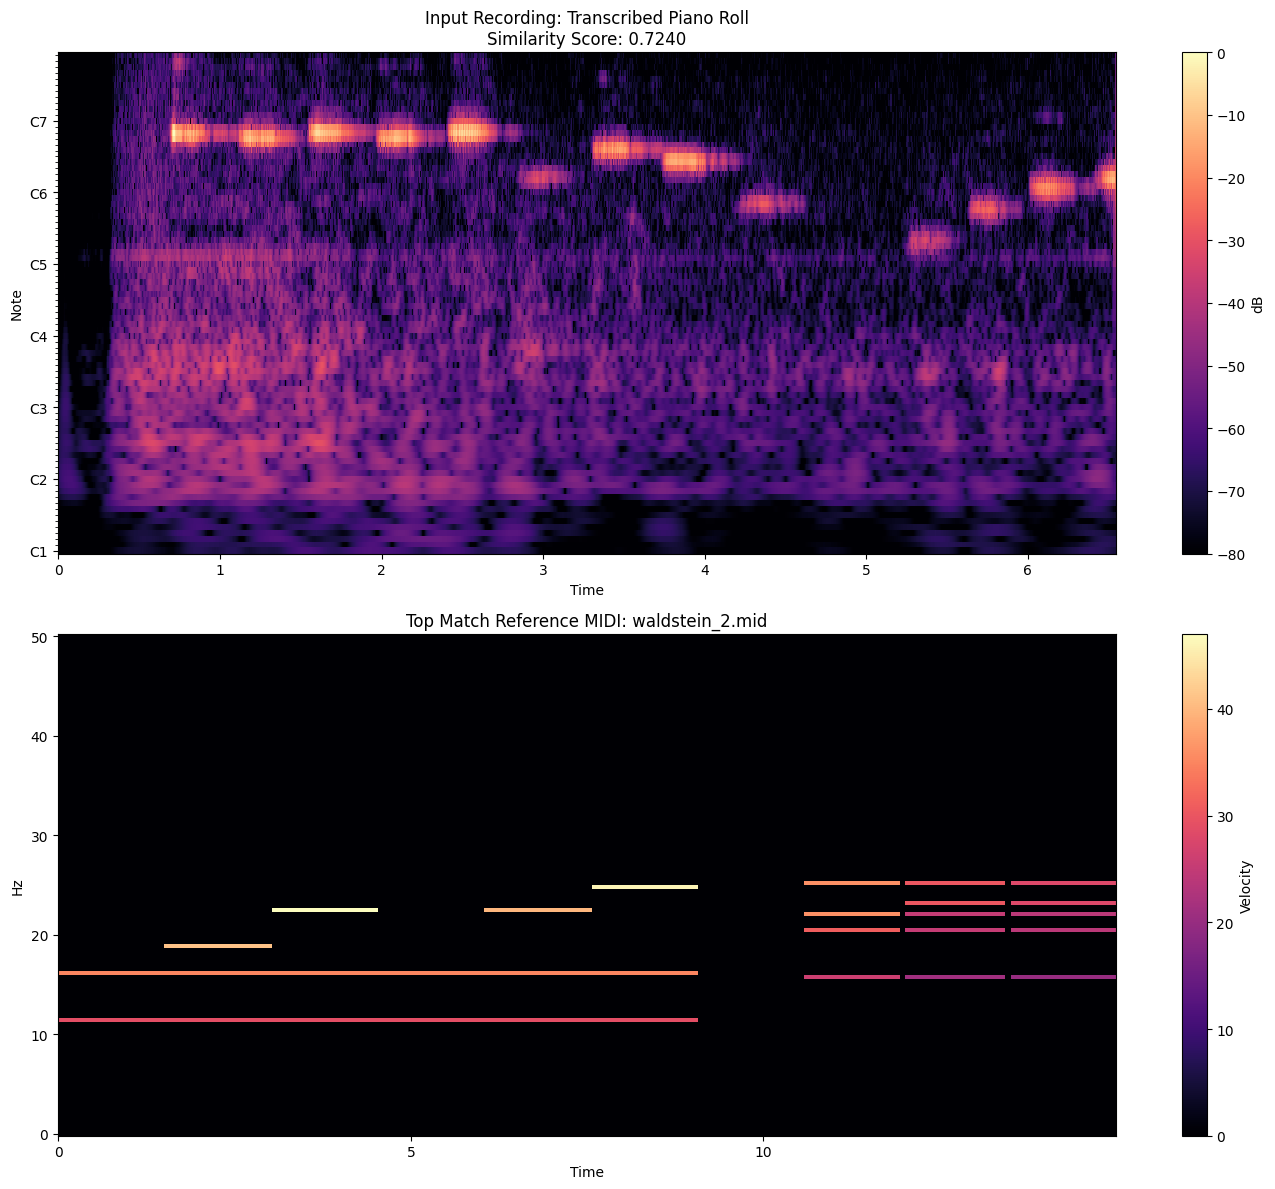

In [91]:
# RUN ENHANCED VISUALIZATION
if chunks_results:
    # Extract match name and the similarity score
    match_name = chunks_results[0]["Matched_File"]
    sim_score = chunks_results[0]["Sim Score"]

    midi_file = find_midi_path(match_name, MIDI_ROOT)

    if midi_file:
        print(f"Match found! Processing transcription for: {midi_file}")

        # --- A. Process Reference MIDI ---
        pm = pretty_midi.PrettyMIDI(midi_file)
        midi_piano_roll = pm.get_piano_roll(fs=100)

        # --- B. Convert Input Waveform to Pseudo-Piano Roll ---
        import numpy as np
        C = librosa.cqt(full_audio, sr=SAMPLING_RATE, hop_length=160, bins_per_octave=12, n_bins=84)
        audio_piano_roll = librosa.amplitude_to_db(np.abs(C), ref=np.max)

        # --- C. Plotting ---
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=False)

        # Plot 1: Input Recording (Transcribed to Notes)
        img1 = librosa.display.specshow(audio_piano_roll,
                                        x_axis='time', y_axis='cqt_note',
                                        sr=SAMPLING_RATE, hop_length=160,
                                        fmin=librosa.note_to_hz('C1'),
                                        ax=ax1, cmap='magma')

        # UPDATED TITLE: Includes the Similarity Score formatted to 4 decimal places
        ax1.set_title(f"Input Recording: Transcribed Piano Roll\nSimilarity Score: {sim_score:.4f}")
        plt.colorbar(img1, ax=ax1, label="dB")

        # Plot 2: Reference MIDI Piano Roll
        img2 = librosa.display.specshow(
            midi_piano_roll[:, :1500],
            x_axis='time',
            y_axis='linear',   # or just remove y_axis entirely
            sr=100,
            hop_length=1,
            ax=ax2,
            cmap='magma'
        )
        ax2.set_title(f"Top Match Reference MIDI: {os.path.basename(midi_file)}")
        plt.colorbar(img2, ax=ax2, label="Velocity")

        plt.tight_layout()
        plt.show()
    else:
        print(f"MIDI file not found for {match_name} in {MIDI_ROOT}")

# Capture microphone audio - BLANK AUDIO (NO WHISTLING) EXAMPLE
setTimeout(r, 7000): The number 7000 is in milliseconds.

In [86]:
# Set microphone recording config
SAMPLING_RATE = 24000
SECONDS = 7
# Function to record microphone audio
def record_audio(sr=SAMPLING_RATE, seconds=SECONDS):
    JS_CODE = f"""
    async function recordAudio() {{
      const stream = await navigator.mediaDevices.getUserMedia({{ audio: true }});
      const mediaRecorder = new MediaRecorder(stream);
      let chunks = [];
      mediaRecorder.ondataavailable = (e) => chunks.push(e.data);
      mediaRecorder.start();
      await new Promise(r => setTimeout(r, {seconds * 1000}));
      mediaRecorder.stop();
      return new Promise(r => mediaRecorder.onstop = () => {{
        const blob = new Blob(chunks);
        const reader = new FileReader();
        reader.readAsDataURL(blob);
        reader.onloadend = () => r(reader.result);
      }});
    }}
    """
    print(f'Recording for {SECONDS} seconds...')
    display(IPython.display.Javascript(JS_CODE))
    audio_data = output.eval_js('recordAudio()')

    # Convert base64 to audio array
    binary = b64decode(audio_data.split(',')[1])
    audio = pydub.AudioSegment.from_file(BytesIO(binary))
    samples = np.array(audio.get_array_of_samples()).astype(np.float32)

    # Resample to match your MERT model requirements (24kHz)
    samples_resampled = librosa.resample(samples, orig_sr=audio.frame_rate, target_sr=sr)
    return samples_resampled

# Capture the audio
full_audio = record_audio(sr=SAMPLING_RATE)

# Create MERT inputs from audio
inputs = processor(
    full_audio,
    sampling_rate=24000,
    return_tensors="pt",
    padding=True
).to(DEVICE)

Recording for 7 seconds...


<IPython.core.display.Javascript object>

# Find best match with Fine-Tuned MERT with LoRA + CNN


In [87]:
# RUN THE MATCHING
chunks_results = []

# Ensure models are in evaluation mode
model.eval()
trained_projector.eval()

try:
    with torch.no_grad():
        # 1. Process recording
        inputs = processor(full_audio, sampling_rate=SAMPLING_RATE, return_tensors="pt").to(DEVICE)
        outputs = model(**inputs, output_hidden_states=True)
        last_hidden = outputs.last_hidden_state

        # 2. Direct Projection (Clean and accurate)
        # Works perfectly with batch size 1 from  track_running_stats=True + .eval()
        chunk_emb = trained_projector(last_hidden)

        # 3. Similarity Search
        chunk_emb_norm = F.normalize(chunk_emb, p=2, dim=1)
        ref_norm = F.normalize(ref_embeddings, p=2, dim=1)
        similarities = torch.mm(chunk_emb_norm, ref_norm.T).squeeze(0)

        top_idx = torch.argmax(similarities).item()
        score = similarities[top_idx].item()
        song_name = ref_names[top_idx]

        chunks_results.append({
            "Matched_File": song_name,
            "Sim Score": score
        })

        print(f"Top Match: {song_name} | Score: {score:.4f}")

except Exception as e:
    print(f"Error during matching: {e}")

Top Match: chpn_op25_e11_chunk_115.wav | Score: 0.8370


# Plot transcribed piano roll with reference piano roll

Match found! Processing transcription for: /content/capstone_team_3/MidiDatasets/590-Classical-music-midi/chopin/chpn_op25_e11.mid


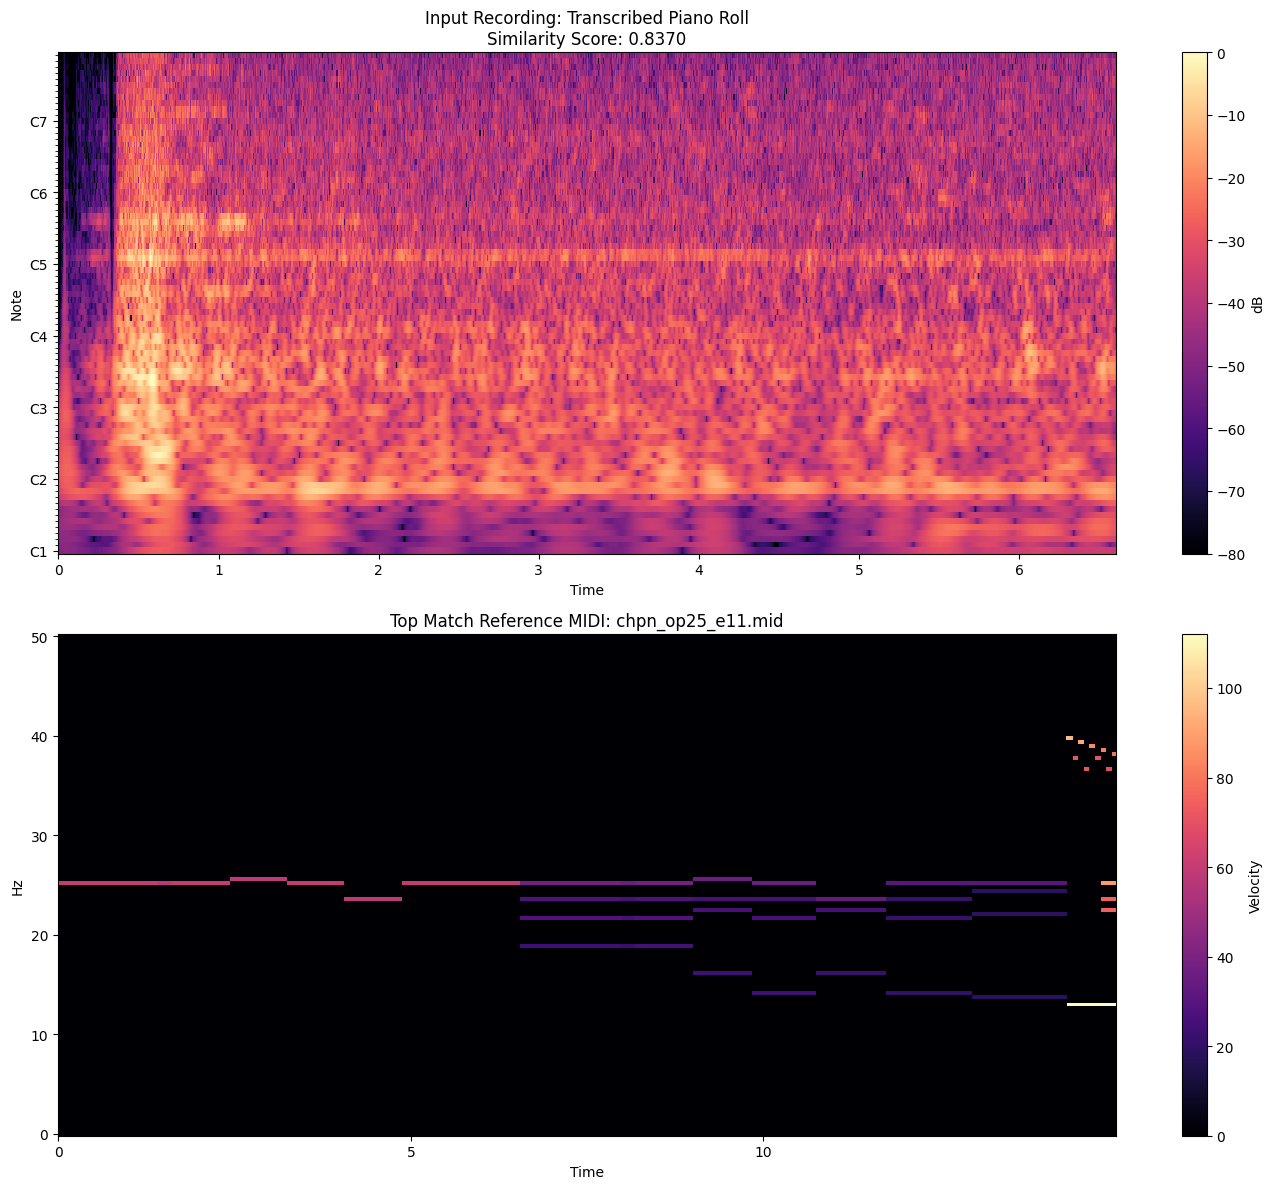

In [88]:
# RUN THE ENHANCED VISUALIZATION
if chunks_results:
    # Extract match name and the similarity score
    match_name = chunks_results[0]["Matched_File"]
    sim_score = chunks_results[0]["Sim Score"]

    midi_file = find_midi_path(match_name, MIDI_ROOT)

    if midi_file:
        print(f"Match found! Processing transcription for: {midi_file}")

        # --- A. Process Reference MIDI ---
        pm = pretty_midi.PrettyMIDI(midi_file)
        midi_piano_roll = pm.get_piano_roll(fs=100)

        # --- B. Convert Input Waveform to Pseudo-Piano Roll ---
        import numpy as np
        C = librosa.cqt(full_audio, sr=SAMPLING_RATE, hop_length=160, bins_per_octave=12, n_bins=84)
        audio_piano_roll = librosa.amplitude_to_db(np.abs(C), ref=np.max)

        # --- C. Plotting ---
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=False)

        # Plot 1: Input Recording (Transcribed to Notes)
        img1 = librosa.display.specshow(audio_piano_roll,
                                        x_axis='time', y_axis='cqt_note',
                                        sr=SAMPLING_RATE, hop_length=160,
                                        fmin=librosa.note_to_hz('C1'),
                                        ax=ax1, cmap='magma')

        # UPDATED TITLE: Includes the Similarity Score formatted to 4 decimal places
        ax1.set_title(f"Input Recording: Transcribed Piano Roll\nSimilarity Score: {sim_score:.4f}")
        plt.colorbar(img1, ax=ax1, label="dB")

        # Plot 2: Reference MIDI Piano Roll
        img2 = librosa.display.specshow(
            midi_piano_roll[:, :1500],
            x_axis='time',
            y_axis='linear',   # or just remove y_axis entirely
            sr=100,
            hop_length=1,
            ax=ax2,
            cmap='magma'
        )
        ax2.set_title(f"Top Match Reference MIDI: {os.path.basename(midi_file)}")
        plt.colorbar(img2, ax=ax2, label="Velocity")

        plt.tight_layout()
        plt.show()
    else:
        print(f"MIDI file not found for {match_name} in {MIDI_ROOT}")